<a href="https://colab.research.google.com/github/Joaopbcardoso/techguard/blob/main/itajai_ndvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo
Realiza a análise de NDVI na imagem "/content/Itajai_Bandas_Originais.tif". Isso inclui a extração das bandas do vermelho (red) e infravermelho próximo (near-infrared), o cálculo do NDVI e a verificação de seu intervalo térmico. O processo abrange a visualização do NDVI, a geração de um histograma, a categorização e a visualização do NDVI classificado. Por fim, deve-se realizar a filtragem do NDVI classificado, visualizar o resultado filtrado e exibir a imagem original para fins de comparação.

## Atualizar o caminho da imagem

Atualizar a variável `filedir` para apontar para o novo arquivo `.tif` da imagem de Itajaí, que assumiremos estar em `/content/itajai_map.tif`.


**Reasoning**:
The subtask requires updating the `filedir` variable to a new path. This code block will modify the `filedir` variable to point to the specified new image file.



In [ ]:
filedir = '/content/Itajai_Bandas_Originais.tif'

## Extract Red and NIR Bands

### Subtask:
Extrair as bandas vermelha (B4) e infravermelho próximo (B8) do novo arquivo `.tif`. Assumiremos que a banda 0 é a vermelha e a banda 1 é a infravermelho próximo, com base em análises anteriores.


In [ ]:
with rasterio.open(filedir) as raster:
    raster_arr = raster.read()

original_image = raster_arr # Store the original for later comparison
B4 = raster_arr[0] # Assuming band 0 is Red
B8 = raster_arr[1] # Assuming band 1 is Near-Infrared

print("Red (B4) and NIR (B8) bands extracted, and original image stored.")

Red (B4) and NIR (B8) bands extracted, and original image stored.


No próximo passo podemos calcular o NVDI


In [ ]:
import numpy as np

np.seterr(divide='ignore', invalid='ignore')

# NDVI
ndvi = (B8.astype(float) - B4.astype(float)) / (B8 + B4)

print("NDVI calculated successfully.")

NDVI calculated successfully.


A partir disso podemos consultar o máximo e o mínimo do íncice em todo o território da imagem.


In [ ]:
print(np.nanmin(ndvi))
print(np.nanmax(ndvi))

-0.8418079096045198
0.9570740254051686


O próximo passo na tarefa geral é a visualização do NDVI calculado. Isso envolve a definição dos valores mínimo, máximo e de um ponto médio personalizado para a normalização, a seleção de uma paleta de cores (colormap) adequada e, em seguida, a plotagem da matriz (array) de NDVI utilizando a função imshow com a normalização personalizada e a respectiva barra de cores (colorbar).


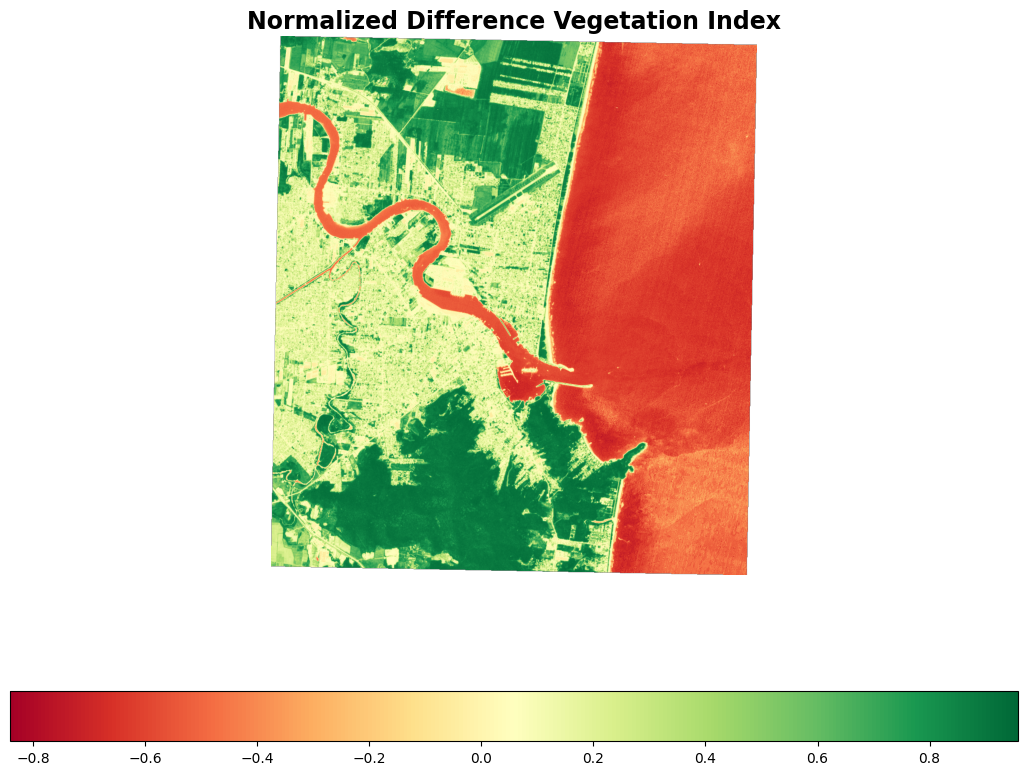

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors

class MidpointNormalize(colors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

min=np.nanmin(ndvi)
max=np.nanmax(ndvi)

mid=0.1

colormap = plt.cm.RdYlGn
norm = MidpointNormalize(vmin=min, vmax=max, midpoint=mid)
fig = plt.figure(figsize=(20,10))


ax = fig.add_subplot(111)

cbar_plot = ax.imshow(ndvi, cmap=colormap, vmin=min, vmax=max)


ax.axis('off')

ax.set_title('Normalized Difference Vegetation Index', fontsize=17, fontweight='bold')

cbar = fig.colorbar(cbar_plot, orientation='horizontal', shrink=0.65)

plt.show()

Podemos também gerar um historiograma da área analisada:



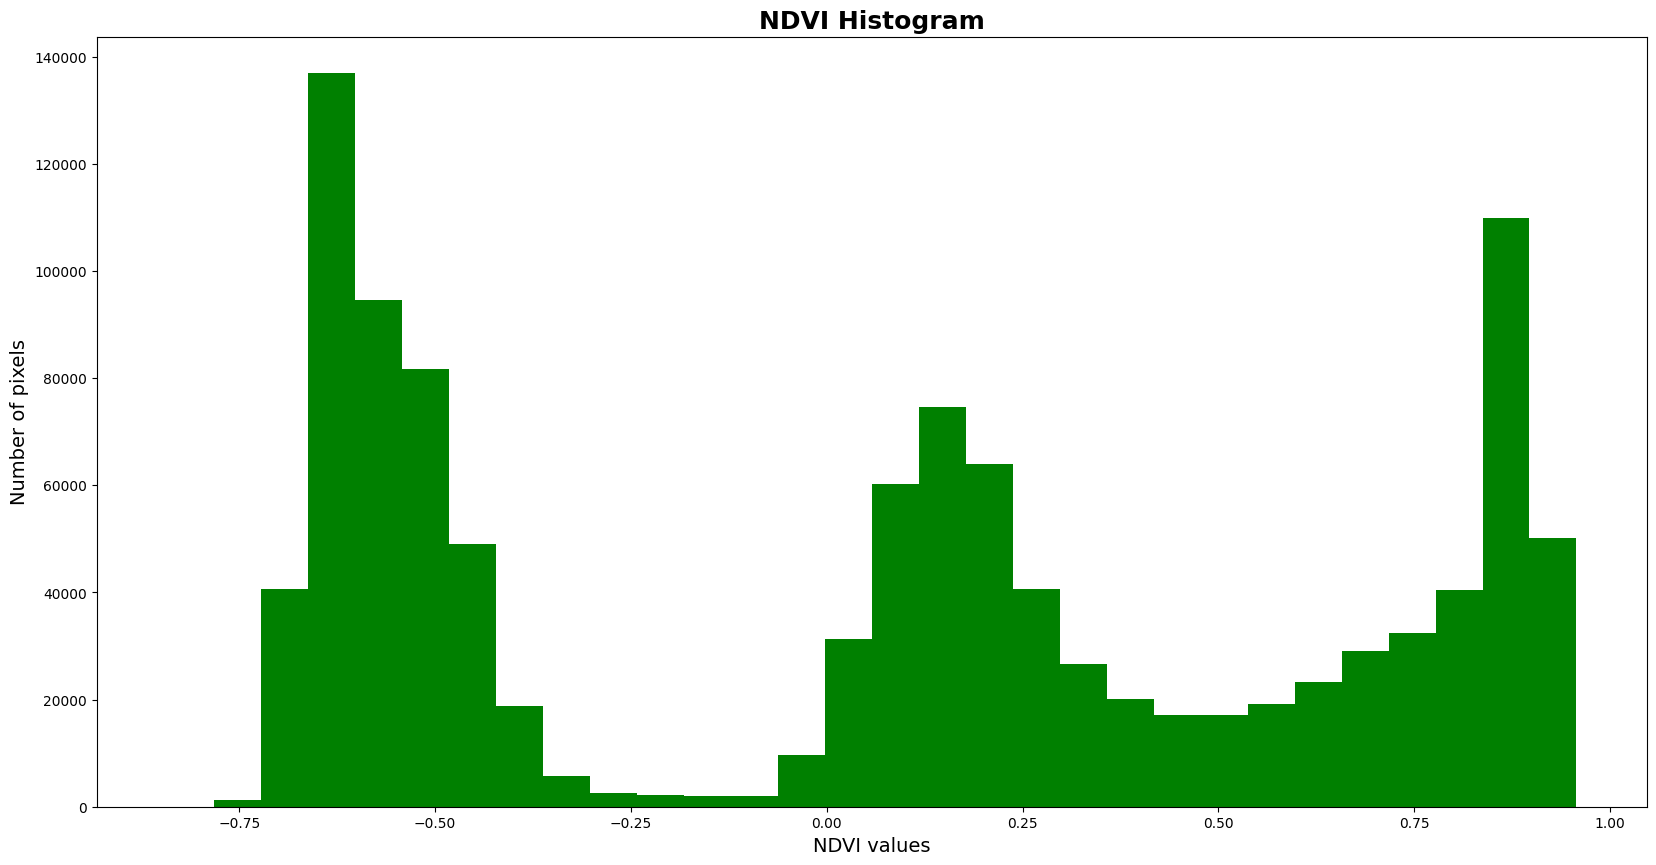

In [ ]:
fig2 = plt.figure(figsize=(20,10))

ax = fig2.add_subplot(111)

plt.title("NDVI Histogram", fontsize=18, fontweight='bold')
plt.xlabel("NDVI values", fontsize=14)
plt.ylabel("Number of pixels", fontsize=14)

x = ndvi[~np.isnan(ndvi)]
color = 'g'
ax.hist(x,bins=30,color=color,histtype='bar', ec='black')

plt.show()

**Reasoning**:
O próximo passo é categorizar os valores de NDVI em intervalos (bins) predefinidos para classificar os diferentes níveis de saúde da vegetação. Isso envolve o uso da função np.digitize para atribuir cada valor de NDVI a uma categoria com base nos valores especificados em ndvi_class_bin e, em seguida, imprimir as categorias exclusivas para verificar a classificação.


In [ ]:
ndvi_class_bin  = [-1, -0.5, 0, 0.25, 0.5, 1]
ndvi_classified = np.digitize(ndvi, ndvi_class_bin)
print(np.unique(ndvi_classified))

[1 2 3 4 5 6]


Após a categorização dos valores de NDVI, o próximo passo consiste na visualização dessas classificações utilizando uma paleta de cores (colormap) personalizada para representar os diferentes níveis de saúde da vegetação. Este procedimento proporcionará uma representação visual clara e intuitiva da imagem de NDVI já categorizada.

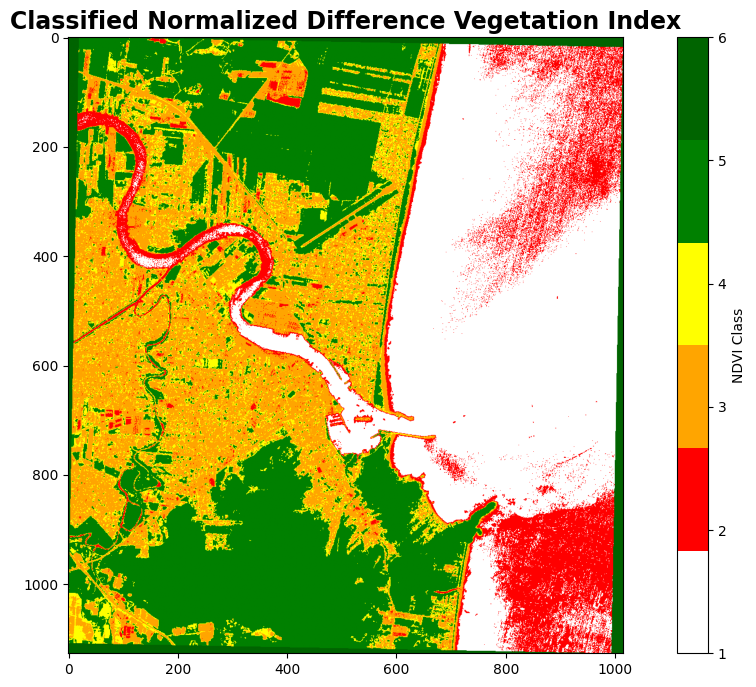

In [ ]:
cmap = colors.ListedColormap(['white', 'red', 'orange', 'yellow', 'green', 'darkgreen'])

plt.figure(figsize=[14,8])
plt.imshow(ndvi_classified, cmap=cmap, vmin=1, vmax=6)
plt.title('Classified Normalized Difference Vegetation Index', fontsize=17, fontweight='bold')
plt.colorbar(label='NDVI Class')
plt.show()

O próximo passo consiste em filtrar a imagem de NDVI já classificada para reduzir ruídos e gerar regiões mais homogêneas. Isso envolve a conversão da matriz (array) ndvi_classified para o tipo inteiro de 8 bits sem sinal (unsigned 8-bit integer), que é um requisito comum para funções de processamento de imagem, como a cv2.medianBlur.

In [ ]:
ndvi_classified = ndvi_classified.astype(np.uint8)
print("NDVI classified array converted to uint8 for filtering.")

NDVI classified array converted to uint8 for filtering.


**Reasoning**:
Após a conversão para uint8, o próximo passo é aplicar um filtro de mediana à imagem de NDVI classificada para reduzir ruídos e gerar regiões mais homogêneas, conforme indicado pelo fluxo de trabalho (workflow) original do notebook.


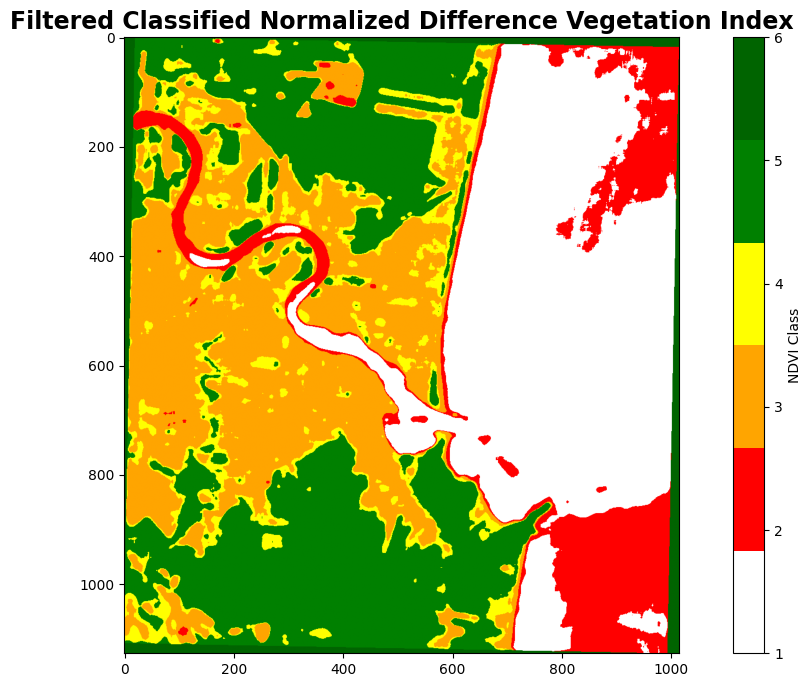

In [ ]:
median = cv2.medianBlur(ndvi_classified, 13)
plt.figure(figsize=[14,8])
plt.imshow(median, cmap=cmap, vmin=1, vmax=6)
plt.title('Filtered Classified Normalized Difference Vegetation Index', fontsize=17, fontweight='bold')
plt.colorbar(label='NDVI Class')
plt.show()